In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np

In [2]:
listings = pd.read_csv('listings.csv')

In [3]:
listings

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
1,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,279,2019-08-29,4.62,1,192
2,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
3,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,75,2019-07-21,0.59,1,13
4,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.39,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48372,38564068,Top Floor Delight,207204450,Ade,Brooklyn,Cypress Hills,40.67618,-73.90764,Entire home/apt,199,2,0,NaN,NaN,4,42
48373,38564524,Central Park Elegance,1567562,Maggie,Manhattan,Upper East Side,40.77326,-73.96650,Entire home/apt,175,30,0,NaN,NaN,1,263
48374,38566777,Quiet room available,159902221,Nancy,Brooklyn,Bushwick,40.69907,-73.93043,Private room,35,30,0,NaN,NaN,1,66
48375,38567542,Spacious room in Brooklyn brownstone,68905617,Eric,Brooklyn,Crown Heights,40.66986,-73.93772,Private room,79,1,0,NaN,NaN,10,322


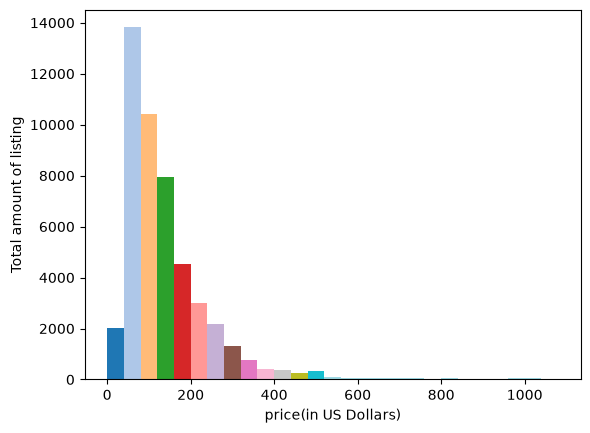

In [4]:
# PRICE DISTRIBUTION ANALYSIS
# This bar chart highlights a heavily right-skewed market: the vast majority of listings cluster tightly under $200, 
# peaking sharply between $50 and $150, while properties priced above $400 drop off into a sparse tail of rare exceptions.
n, bins, patches = plt.hist(listings['price'], np.arange(0, 1100, 40))

colors = plt.cm.tab20(np.linspace(0, 2, len(patches)))
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)
plt.xlabel('price(in US Dollars)')
plt.ylabel('Total amount of listing')
plt.show()

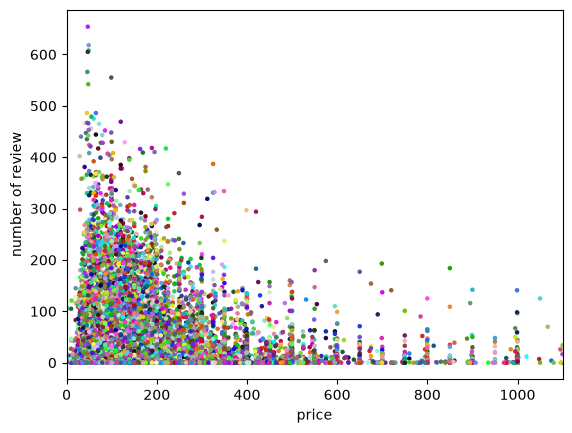

In [5]:
# SCATTER PLOT ANALYSIS: PRICE vs. NUMBER OF REVIEWS

# Inverse Relationship & Concentration: The vast majority of listings are heavily concentrated in the lower price brackets 
# (under $200) and lower-to-moderate review ranges (0 to 300 reviews). As the price increases, the density of listings drops significantly,
# showing an inverse pattern where higher-priced properties tend to accumulate fewer reviews overall.

# Engagement Clustering: High review counts (exceeding 400 reviews) are almost exclusively restricted to properties priced below $200, 
# suggesting that more affordable listings drive higher booking frequency and customer feedback volume.

# Outliers: A sparse spread of properties exists in the higher price tiers ($400 to $1,000+), 
# almost all of which cluster near the bottom with minimal reviews.

random_colors = np.random.rand(len(listings), 3)  # random RGB color per dot
plt.scatter(x = listings['price'], y = listings['number_of_reviews'], s = 5, c = random_colors)
plt.xlabel('price')
plt.ylabel('number of review')
plt.xlim(0, 1100)
plt.show()

In [6]:
# Imagine zooming past the big-picture scatter plot to inspect a very specific corner of the market: 
# properties priced at $200 that have earned precisely 50 reviews.

# This line of code acts as a targeted lens that filters the entire dataset, asking a single, sharp question: 
# How many listings occupy this exact sweet spot? Instead of guessing from a crowded graph, it cuts through the noise to give you a hard count, 
# revealing whether this specific combination of pricing and customer feedback is a common market trend or a rare outlier.

exact_match = listings[(listings['price'] == 200) & (listings['number_of_reviews'] == 50)]
print(len(exact_match))

5
